### Análisis de los logs de movimiento del motor y los datos de la cámara


In [49]:
import numpy as np
import pandas as pd
import glob
import time
from scipy  import stats
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skl
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import statsmodels.api as sm


In [50]:

df_root = r'C:\Users\inges\OneDrive - UDIT\src\photoneu\github\photoneu\photoneu\raspberryPi\logs'
#df_name += r'\2025_06_20_03_40_16_no_cam.log' #\2024_08_29_04_18_52.log'
#df_name += r'\2025_06_20_03_36_37_no_cam.log'
#df_name += r'\2025_06_20_03_44_17.log'
df_name = df_root + r'\2025_06_20_03_47_28.log'
#df_name += r'\2025_06_19_02_20_29.log'

df = pd.read_csv(df_name)

In [56]:
archivos

['C:\\Users\\inges\\OneDrive - UDIT\\src\\photoneu\\github\\photoneu\\photoneu\\raspberryPi\\logs\\2024_06_10_02_19_54.log',
 'C:\\Users\\inges\\OneDrive - UDIT\\src\\photoneu\\github\\photoneu\\photoneu\\raspberryPi\\logs\\2024_06_10_02_24_06.log',
 'C:\\Users\\inges\\OneDrive - UDIT\\src\\photoneu\\github\\photoneu\\photoneu\\raspberryPi\\logs\\2024_06_10_02_44_20.log',
 'C:\\Users\\inges\\OneDrive - UDIT\\src\\photoneu\\github\\photoneu\\photoneu\\raspberryPi\\logs\\2024_06_10_03_00_32.log',
 'C:\\Users\\inges\\OneDrive - UDIT\\src\\photoneu\\github\\photoneu\\photoneu\\raspberryPi\\logs\\2024_06_10_04_49_53.log',
 'C:\\Users\\inges\\OneDrive - UDIT\\src\\photoneu\\github\\photoneu\\photoneu\\raspberryPi\\logs\\2024_06_10_05_20_40.log',
 'C:\\Users\\inges\\OneDrive - UDIT\\src\\photoneu\\github\\photoneu\\photoneu\\raspberryPi\\logs\\2024_07_30_03_51_05.log',
 'C:\\Users\\inges\\OneDrive - UDIT\\src\\photoneu\\github\\photoneu\\photoneu\\raspberryPi\\logs\\2024_07_30_03_55_27.log',


In [80]:
# Opción 1: Si los archivos tienen un patrón en el nombre (recomendado)
archivos = glob.glob(df_root + r'\*.log')  # Cambia la ruta y patrón según necesites
# archivos = ['archivo1.csv', 'archivo2.csv', 'archivo3.csv', 'archivo4.csv', 'archivo5.csv']

df = pd.concat((pd.read_csv(f) for f in archivos), ignore_index=True)

print(f"DataFrame combinado con {len(df)} registros")
print(df.head())

DataFrame combinado con 332 registros
    t_total   t_motor   t_cam_1    t_cam2           time_motor  motor_x  \
0  1.956258  1.948452  0.003488  0.003542  1750426416370056692     6000   
1  0.865873  0.660073  0.196396  0.004196  1750426417043266143    10000   
2  1.641259  1.629580  0.004486  0.006093  1750426418875706345    14000   
3  2.002026  1.801444  0.195200  0.002498  1750426420690365549     6000   
4  3.309786  3.302420  0.004279  0.002655  1750426424191993266     2000   

   motor_y             time_cam  cam_x  cam_y  
0    22000  1750426416373540071    125    219  
1    22000  1750426417239662555     84    225  
2    14000  1750426418880191284     37    143  
3     6000  1750426420885568948    125     53  
4    22000  1750426424196273949    168    221  


- t_motor, desde moveMotor() hasta llegar al SP.
- t_cam_1, desde llega al SP hasta que detecta que empieza a moverse.

In [66]:
df.columns

Index(['t_total', ' t_motor', ' t_cam_1', ' t_cam2', ' time_motor', 'motor_x',
       'motor_y', 'time_cam', 'cam_x', 'cam_y'],
      dtype='object')

In [67]:
df.head()

,t_total,t_motor,t_cam_1,t_cam2,time_motor,motor_x,motor_y,time_cam,cam_x,cam_y
0,2.887644,2.424658,0.460863,0.001461,1750335648441685230,2000,2000,1750335648902592159,169,10
1,2.161163,1.648814,0.510384,0.001552,1750335650553747839,10000,6000,1750335651064185850,79,55
2,1.413100,0.821444,0.589546,0.001559,1750335651888604875,10000,2000,1750335652478193626,80,10
3,3.222131,2.696660,0.523316,0.001638,1750335655177504660,2000,14000,1750335655700816918,167,141
4,1.497360,0.821566,0.673371,0.001782,1750335656525226373,2000,10000,1750335657198595951,167,98


Depende el retardo de la distancia de movimiento?


In [81]:

df['distancia'] = np.sqrt((df['motor_x'] - df['motor_x'].shift(1))**2 + (df['motor_y'] - df['motor_y'].shift(1))**2)

# Reemplazar NaN por 0 o cualquier valor que se prefiera para la primera observación
df['distancia'].fillna(0, inplace=True)

df["t_cam"] = df[" t_cam_1"] + df[" t_cam2"]

C:\Users\inges\AppData\Local\Temp\ipykernel_13252\4214303564.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['distancia'].fillna(0, inplace=True)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


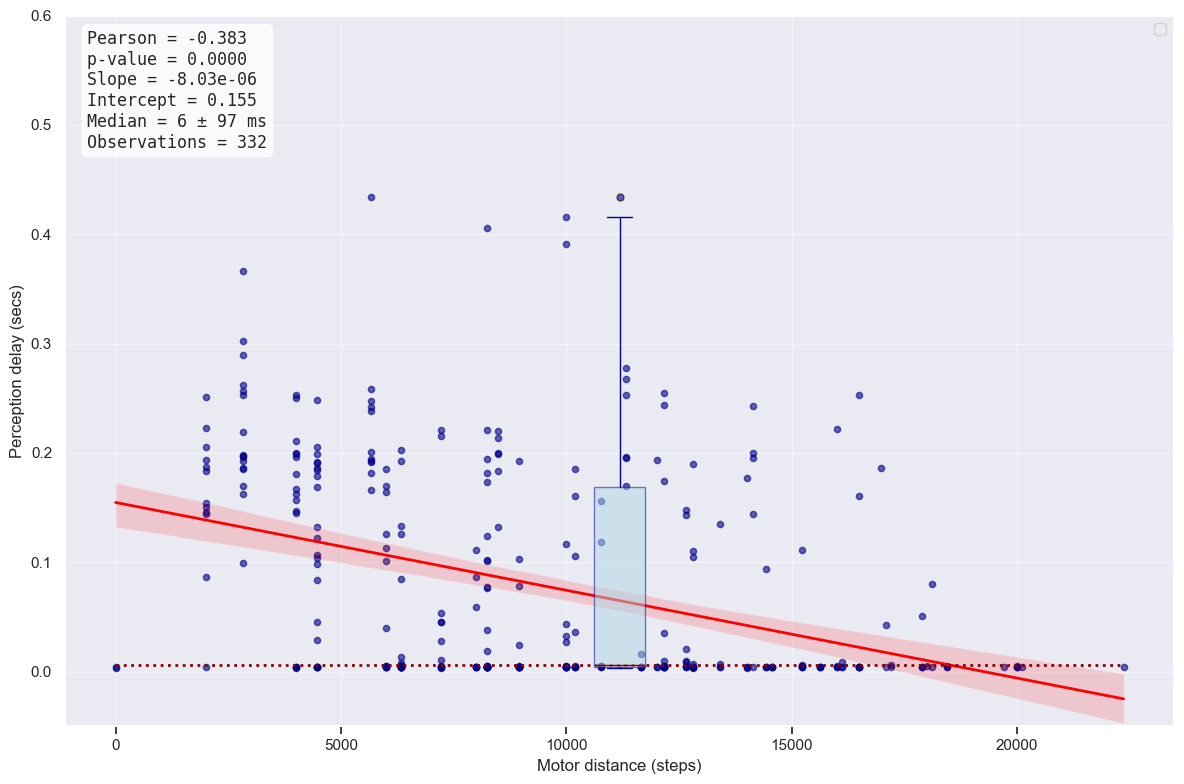

In [135]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Datos estadísticos
m = df[' t_cam_1'].median()
s = df[' t_cam_1'].std()

# Crear figura
fig, ax1 = plt.subplots(figsize=(12, 8))

# --- Scatter plot ---
df.plot(kind="scatter", x="distancia", y=" t_cam_1", marker="o", 
        color="DarkBlue", alpha=0.6, ax=ax1)

# --- Regresión lineal con Seaborn (para el margen de error) ---
sns.regplot(
    data=df, x="distancia", y=" t_cam_1", 
    scatter=False,
    line_kws={'color': 'red', 'label': 'Regresión lineal', 'linewidth': 2},
    ci=95,
    ax=ax1
)

# --- Cálculo de estadísticos ---
# Coeficiente de Pearson y valor-p
pearson_coef, p_value = pearsonr(df['distancia'], df[' t_cam_1'])
# Pendiente e intercepto (vía polyfit)
pendiente, intercepto = np.polyfit(df['distancia'], df[' t_cam_1'], 1)

# --- Texto con los resultados ---
stats_text = (
    f"Pearson = {pearson_coef:.3f}\n"
    f"p-value = {p_value:.4f}\n"
    f"Slope = {pendiente:.2e}\n"
    f"Intercept = {intercepto:.3f}\n"
    f"Median = {m*1000:.0f} ± {s*1000:.0f} ms\n"
    f"Observations = {len(df)}"
)
ax1.text(
    0.02, 0.98, stats_text,
    transform=ax1.transAxes,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
    fontfamily='monospace'
)

# --- Línea de la mediana ---
ax1.plot(
    [df['distancia'].min(), df['distancia'].max()],
    [m, m],
    linestyle='dotted',
    linewidth=2,
    color='darkred'
)

# Ajustes de ejes y leyenda
ax1.set_ylabel("Perception delay (secs)")
ax1.set_xlabel("Motor distance (steps)")
ax1.legend(loc='upper right')
ax1.grid(which='both', alpha=0.4)

# --- Boxplot en eje secundario ---
ax2 = ax1.twiny()
#boxplot_x_position = df['distancia'].max() * 1.05  # 5% más allá del máximo
boxplot_x_position = df['distancia'].max() * 0.5  # 5% más allá del máximo
bp = ax2.boxplot(
    df[' t_cam_1'],
    positions=[boxplot_x_position],
    widths=df['distancia'].max() * 0.05,  # Ancho relativo al rango de datos
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', color='DarkBlue', alpha=0.5),
    medianprops=dict(color='darkred'),
    whiskerprops=dict(color='DarkBlue'),
    capprops=dict(color='DarkBlue'),
    flierprops=dict(marker='o', markersize=5, markerfacecolor='DarkBlue', alpha=0.6)
)

ax2.set_xlim(ax1.get_xlim())
ax2.set_xticks([])
plt.ylim(-0.05, 0.6)

plt.tight_layout()
plt.show()

Hay una correlación débil, pero significativa. 

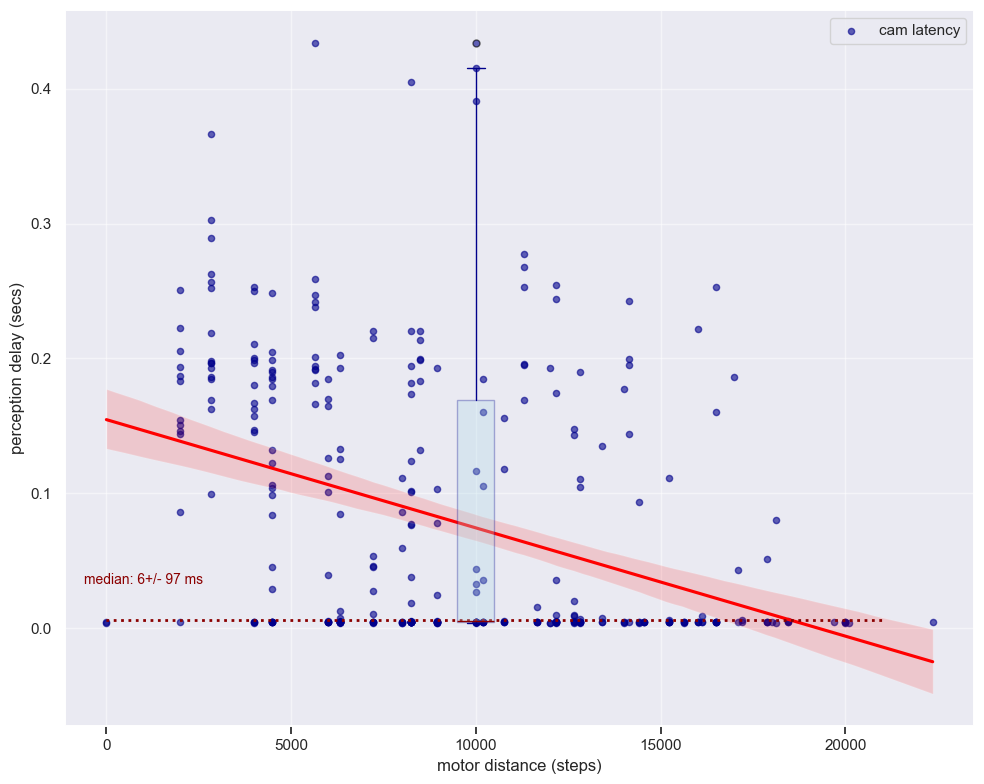

In [132]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  # Solo para la regresión

m = df[' t_cam_1'].median()
s = df[' t_cam_1'].std()

fig, ax1 = plt.subplots(figsize=(10, 8))

# Scatter plot original
df.plot(kind="scatter", x="distancia", y=" t_cam_1", marker="o", 
        color="DarkBlue", label="cam latency", 
        alpha=0.6, ax=ax1)

ax1.grid(which='both')
ax1.grid(which='minor', alpha=0.2)
ax1.grid(which='major', alpha=0.5)

# --- Línea de regresión con margen de error (como sns.lmplot) ---
sns.regplot(
    data=df, x="distancia", y=" t_cam_1", 
    scatter=False,  # Ya tenemos el scatter plot
    line_kws={'color': 'red', 'label': 'Regresión lineal'},  # Línea continua roja
    ci=95,  # Intervalo de confianza del 95% (margen de error)
    ax=ax1  # Dibujar en el mismo eje (ax1)
)

# Línea de la mediana
l = m*np.ones(21000)
ax1.plot(l, linestyle='dotted', linewidth=2, color='darkred')
ax1.text(1000, m + 0.03, 'median: ' + f'{m*1000:.0f}'+ "+/- " + f'{s*1000:.0f}' + " ms", 
         ha='center', va='center', color='darkred', fontsize=10)

ax1.set_ylabel("perception delay (secs)")
ax1.set_xlabel("motor distance (steps)")

# Boxplot (eje secundario)
ax2 = ax1.twiny()
boxplot_x_position = 10000
bp = ax2.boxplot(df[' t_cam_1'], positions=[boxplot_x_position], widths=1000,
                patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='DarkBlue', alpha=0.3),
                medianprops=dict(color='darkred'),
                whiskerprops=dict(color='DarkBlue'),
                capprops=dict(color='DarkBlue'),
                flierprops=dict(marker='o', markersize=5, 
                               markerfacecolor='DarkBlue', alpha=0.6))

ax2.set_xlim(ax1.get_xlim())
ax2.set_xticks([])

# Añadir leyenda
ax1.legend(loc='upper right')

plt.tight_layout()
plt.show()

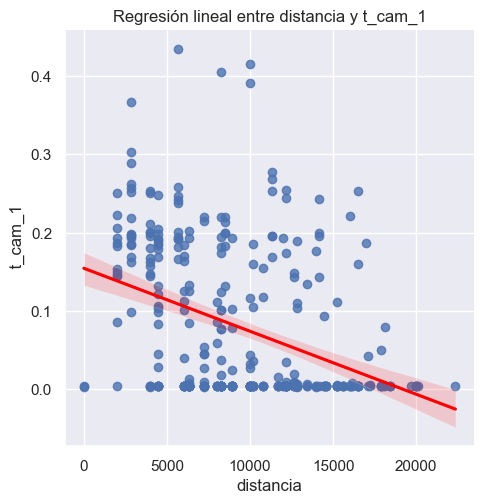

In [123]:
sns.lmplot(data=df, x='distancia', y=' t_cam_1', line_kws={'color': 'red'})
plt.title('Regresión lineal entre distancia y t_cam_1')
plt.show()

In [124]:
from scipy.stats import pearsonr

correlacion = df[[' t_cam_1', 'distancia']].corr(method='pearson')
print(correlacion)

corr, p_value = pearsonr(df['distancia'], df[' t_cam_1'])
print(f"Coeficiente Pearson: {corr:.3f}, Valor-p: {p_value:.5f}")

            t_cam_1  distancia
 t_cam_1   1.000000  -0.382846
distancia -0.382846   1.000000
Coeficiente Pearson: -0.383, Valor-p: 0.00000


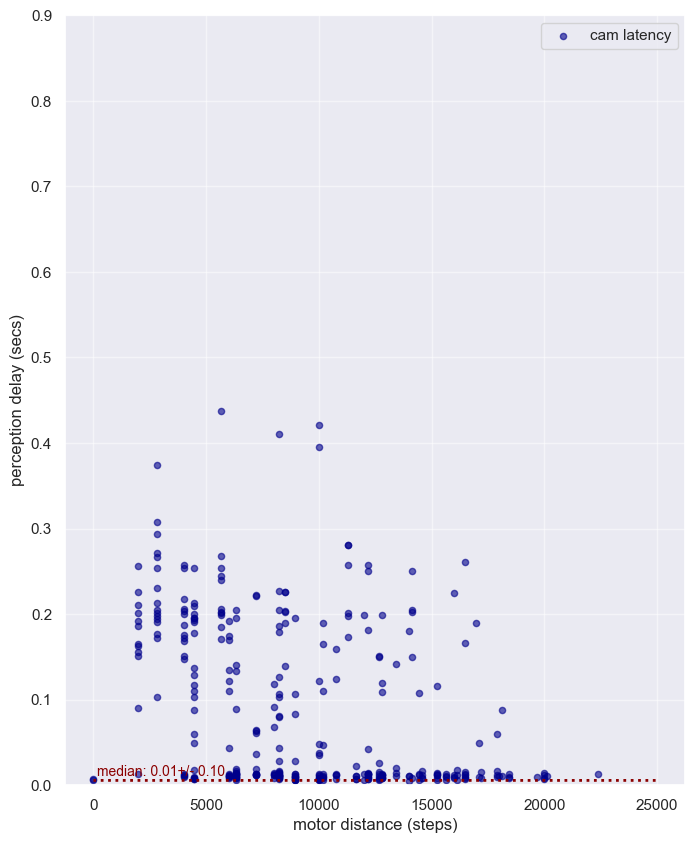

In [125]:
m = df[' t_cam_1'].median()
s = df[' t_cam_1'].std()

ax1 = df.plot(kind="scatter", x="distancia", y="t_cam", marker="o", \
                    color = "DarkBlue", label="cam latency", \
                    alpha = 0.6, figsize=(8,10))
ax1.grid(which='both')
# Or if you want different settings for the grids:
ax1.grid(which='minor', alpha=0.2)
ax1.grid(which='major', alpha=0.5)
#plt.title("Cam Lantency vs Motor movement Distance")
l = m*np.ones(25000)
plt.plot(l, linestyle = 'dotted', linewidth=2, color='darkred')
plt.text(3000, m + 0.01, 'median: ' + f'{m:.2f}'+ "+/- " + f'{s:.2f}' , ha='center', va='center', color='darkred', fontsize=10)
plt.ylim(0, 0.9)
plt.ylabel("perception delay (secs)")
plt.xlabel("motor distance (steps)")
plt.show()

Nos fijamos en t_cam

0.0055670635
0.09695617488255212


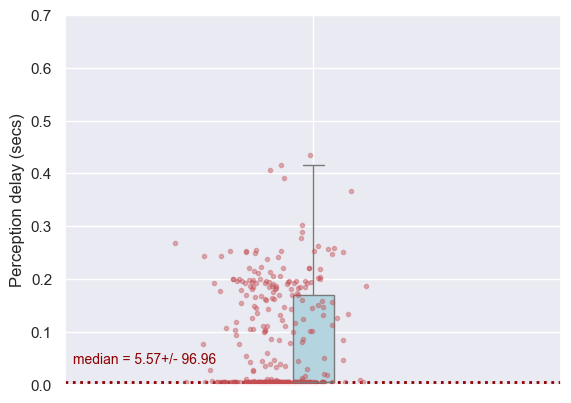

In [129]:

m = df[' t_cam_1'].median()
s = df[' t_cam_1'].std()
x = np.random.normal(-0.04,0.04,size=len(df[' t_cam_1']))
print(m)
print(s)
plt.figure()
sns.boxplot(df[' t_cam_1'],fill=True, width=0.05,color="lightblue", fliersize=0)
#sns.violinplot(df['t_cam'],fill=True)
plt.text(x = -0.29, y = 0.04, s="median = " + f'{m*1000:.2f}'+ "+/- " + f'{s*1000:.2f}', fontsize=10, color='darkred')
#plt.text(x = 0.05, y = 2.2, s=f"std = {s:.2f}" )
plt.hlines(m, -0.3, 0.3, colors='darkred', linestyles='dotted', linewidth=2)
plt.xlim(-0.3,0.3)
plt.ylim(0,0.7)
plt.plot(x, df[' t_cam_1'], 'r.', alpha=0.4)
#plt.title('Mediana de número de ratones detectados por imagen.')
plt.ylabel('Perception delay (secs)')

plt.grid(True)
plt.show()


array([[<Axes: title={'center': 't_total'}>,
        <Axes: title={'center': ' t_motor'}>,
        <Axes: title={'center': ' t_cam_1'}>],
       [<Axes: title={'center': ' t_cam2'}>,
        <Axes: title={'center': ' time_motor'}>,
        <Axes: title={'center': 'motor_x'}>],
       [<Axes: title={'center': 'motor_y'}>,
        <Axes: title={'center': 'time_cam'}>,
        <Axes: title={'center': 'cam_x'}>],
       [<Axes: title={'center': 'cam_y'}>,
        <Axes: title={'center': 'distancia'}>,
        <Axes: title={'center': 't_cam'}>]], dtype=object)

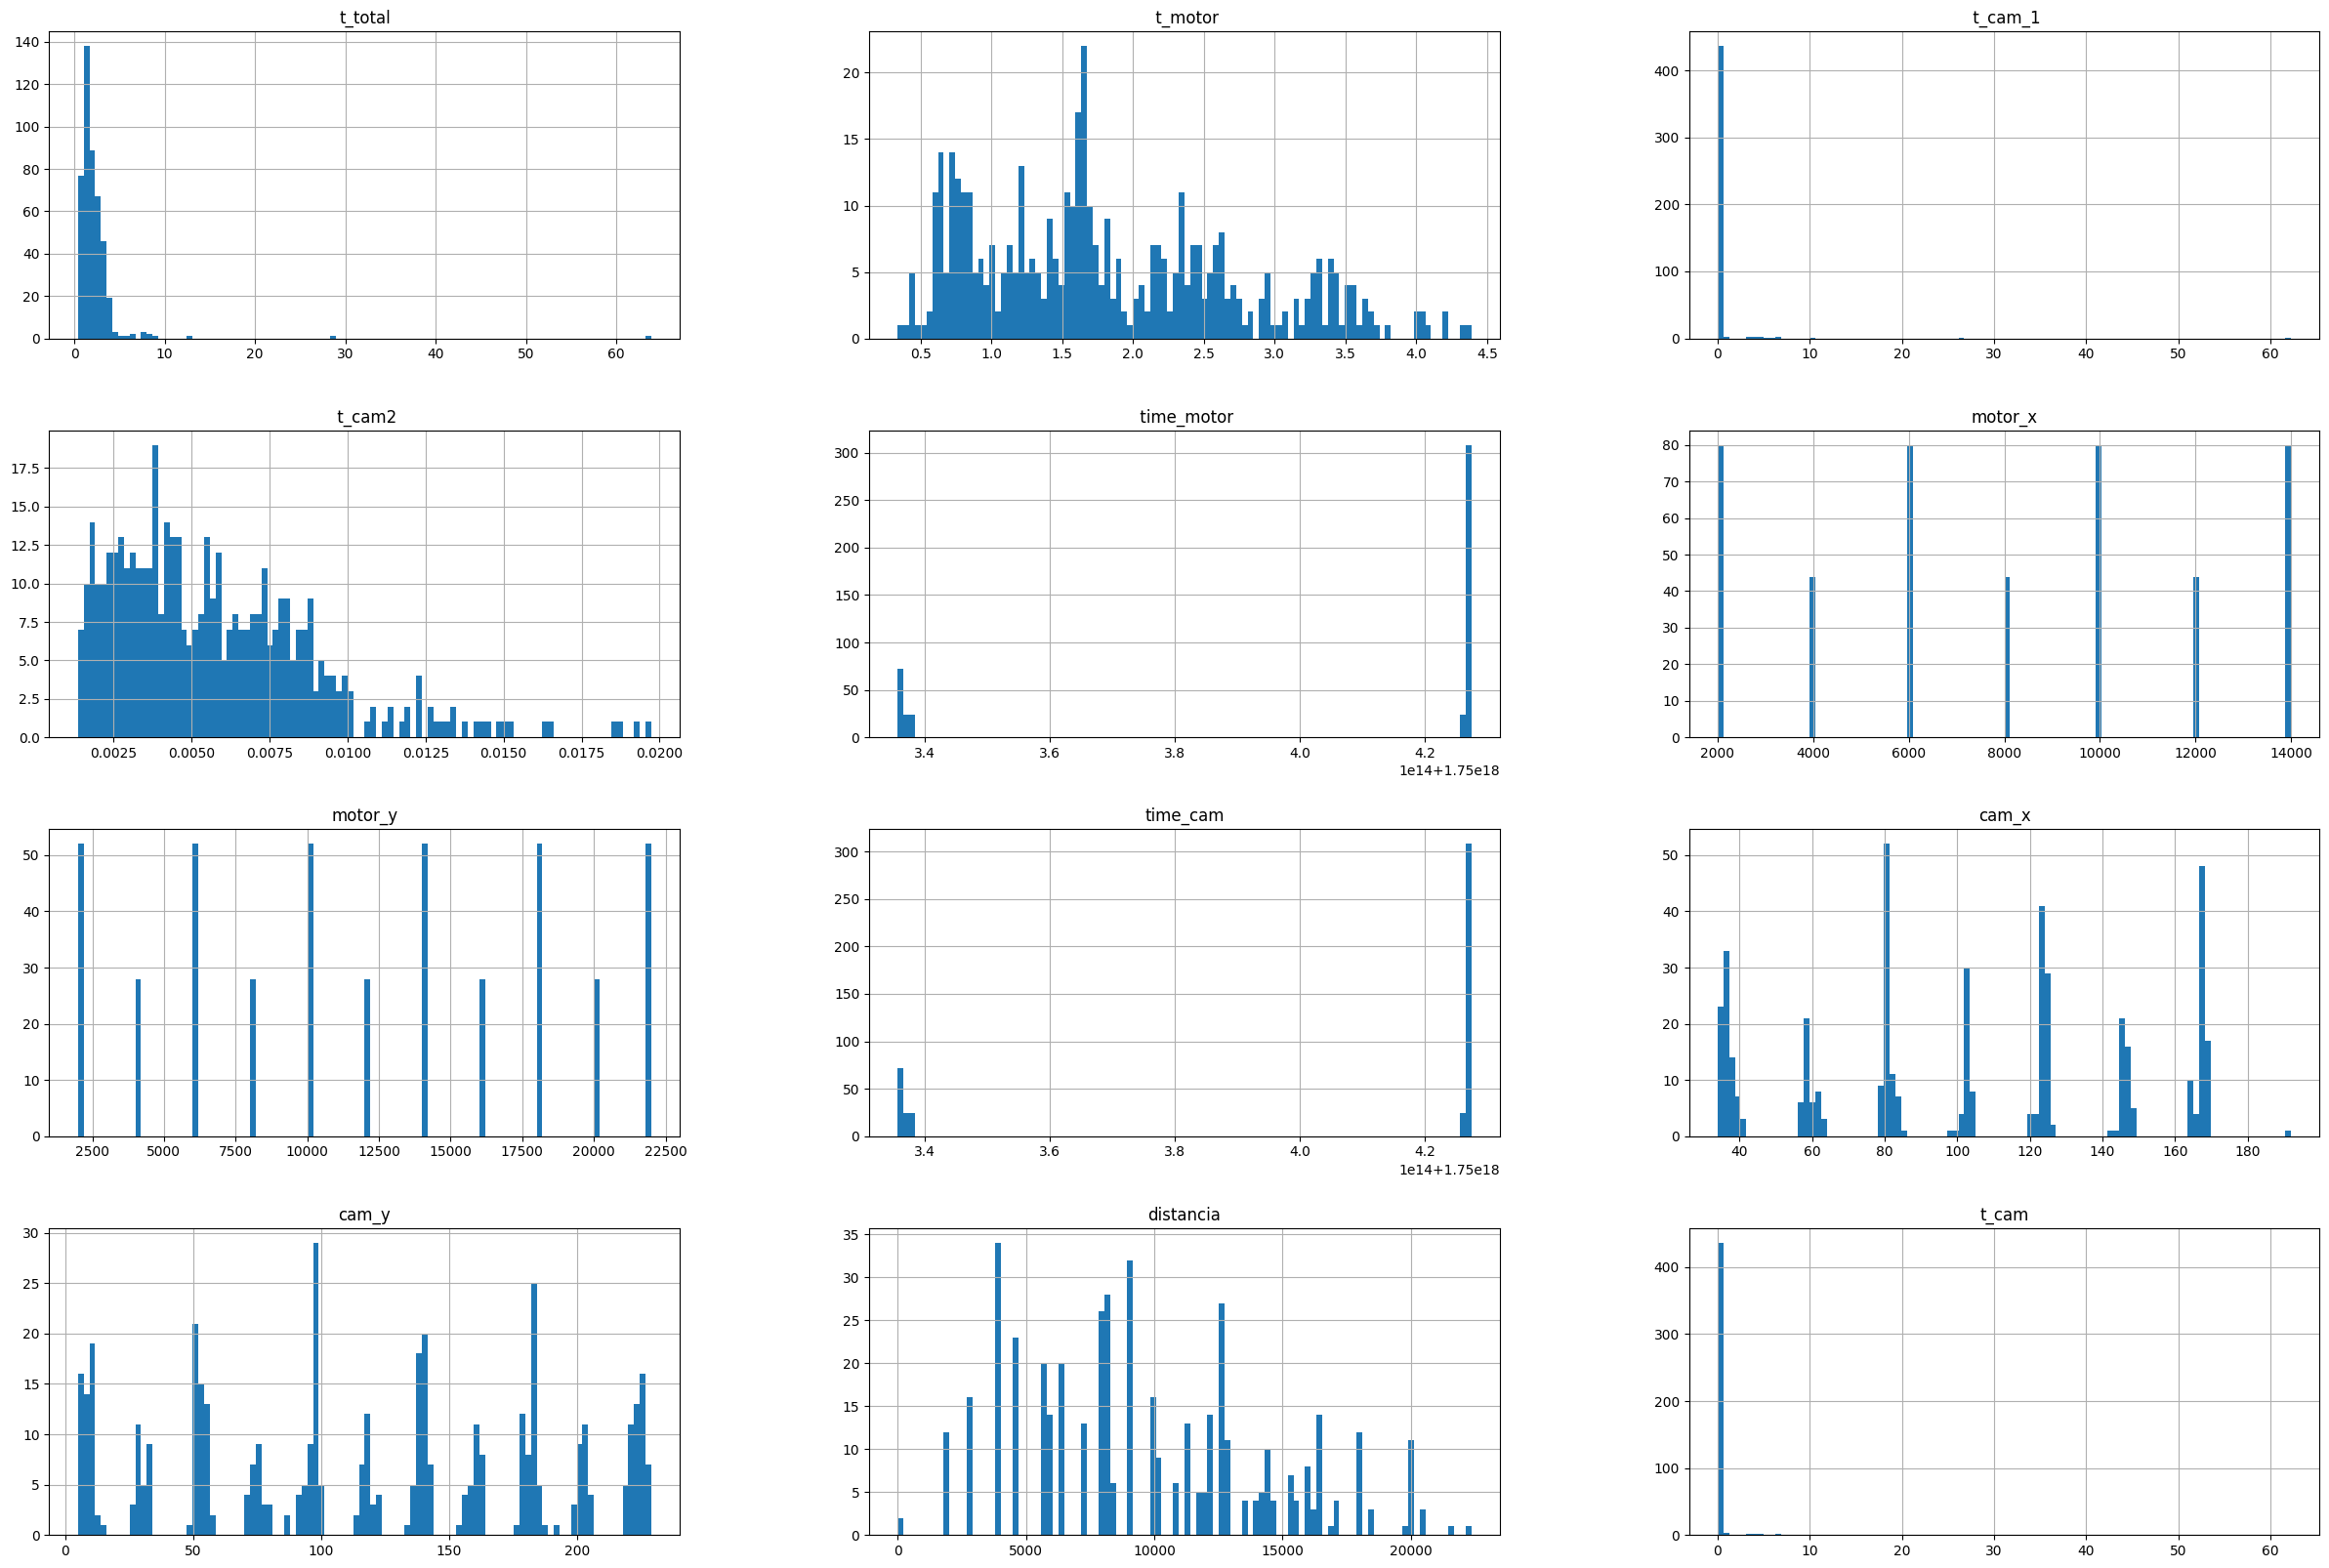

In [72]:
df.hist(bins=100, figsize=(30,20))

In [73]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
t_total,452.0,2.261884e+00,3.413535e+00,4.134663e-01,1.199827e+00,1.717431e+00,2.607489e+00,6.385396e+01
t_motor,452.0,1.813463e+00,9.182495e-01,3.402835e-01,1.070718e+00,1.651092e+00,2.425308e+00,4.386687e+00
t_cam_1,452.0,4.412341e-01,3.284661e+00,3.460055e-03,4.304236e-03,5.126331e-02,1.959793e-01,6.221268e+01
t_cam2,452.0,5.705213e-03,3.261515e-03,1.354871e-03,3.264458e-03,5.052259e-03,7.573514e-03,1.973318e-02
time_motor,452.0,1.750403e+18,3.996805e+13,1.750336e+18,1.750338e+18,1.750427e+18,1.750427e+18,1.750427e+18
motor_x,452.0,8.000000e+03,4.160846e+03,2.000000e+03,4.000000e+03,8.000000e+03,1.200000e+04,1.400000e+04
motor_y,452.0,1.200000e+04,6.497484e+03,2.000000e+03,6.000000e+03,1.200000e+04,1.800000e+04,2.200000e+04
time_cam,452.0,1.750403e+18,3.996744e+13,1.750336e+18,1.750338e+18,1.750427e+18,1.750427e+18,1.750427e+18
cam_x,452.0,1.024535e+02,4.539191e+01,3.400000e+01,6.075000e+01,1.030000e+02,1.460000e+02,1.920000e+02
cam_y,452.0,1.173009e+02,6.975992e+01,5.000000e+00,5.400000e+01,1.180000e+02,1.802500e+02,2.290000e+02


In [74]:
#df['t_cam'].mean()
df['t_cam'].describe()

count    452.000000
mean       0.446939
std        3.284549
min        0.005309
25%        0.010801
50%        0.062233
75%        0.201899
max       62.218097
Name: t_cam, dtype: float64

<Axes: >

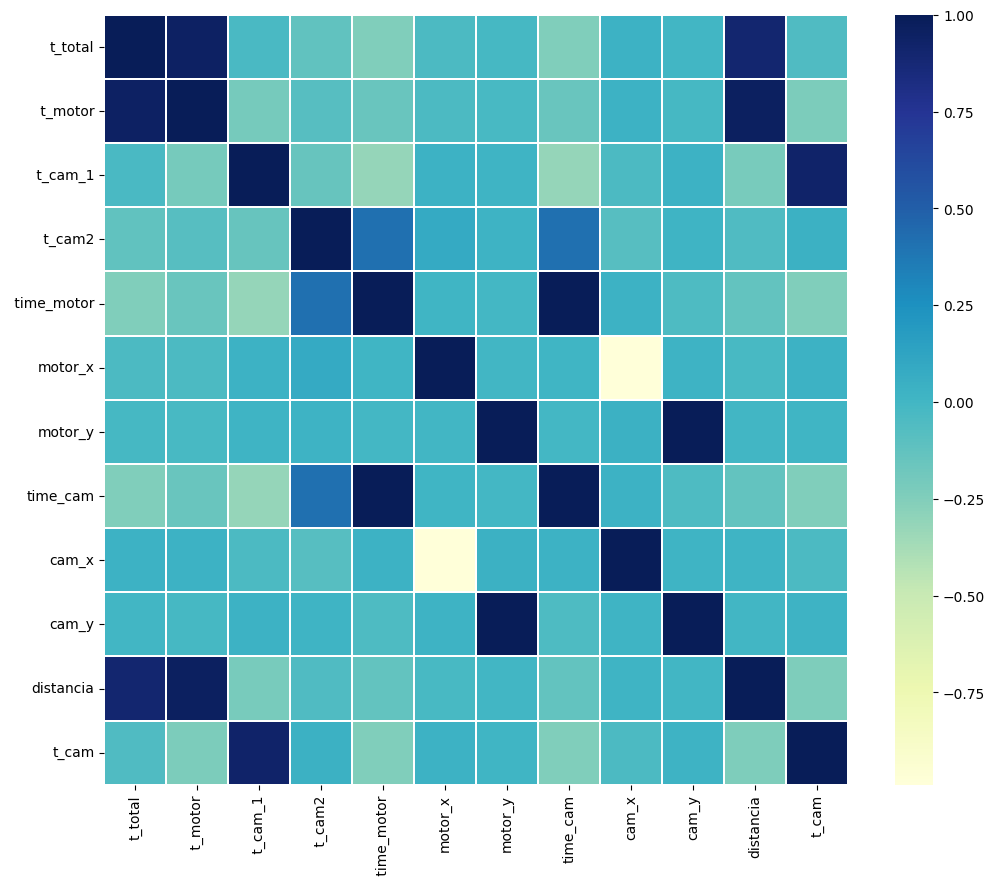

In [75]:
corrmat = df.corr(method='spearman',numeric_only=True)
f, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corrmat, ax=ax, cmap="YlGnBu", linewidths=0.1)

c:\ProgramData\anaconda3\envs\DEEPLABCUT\lib\site-packages\seaborn\axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


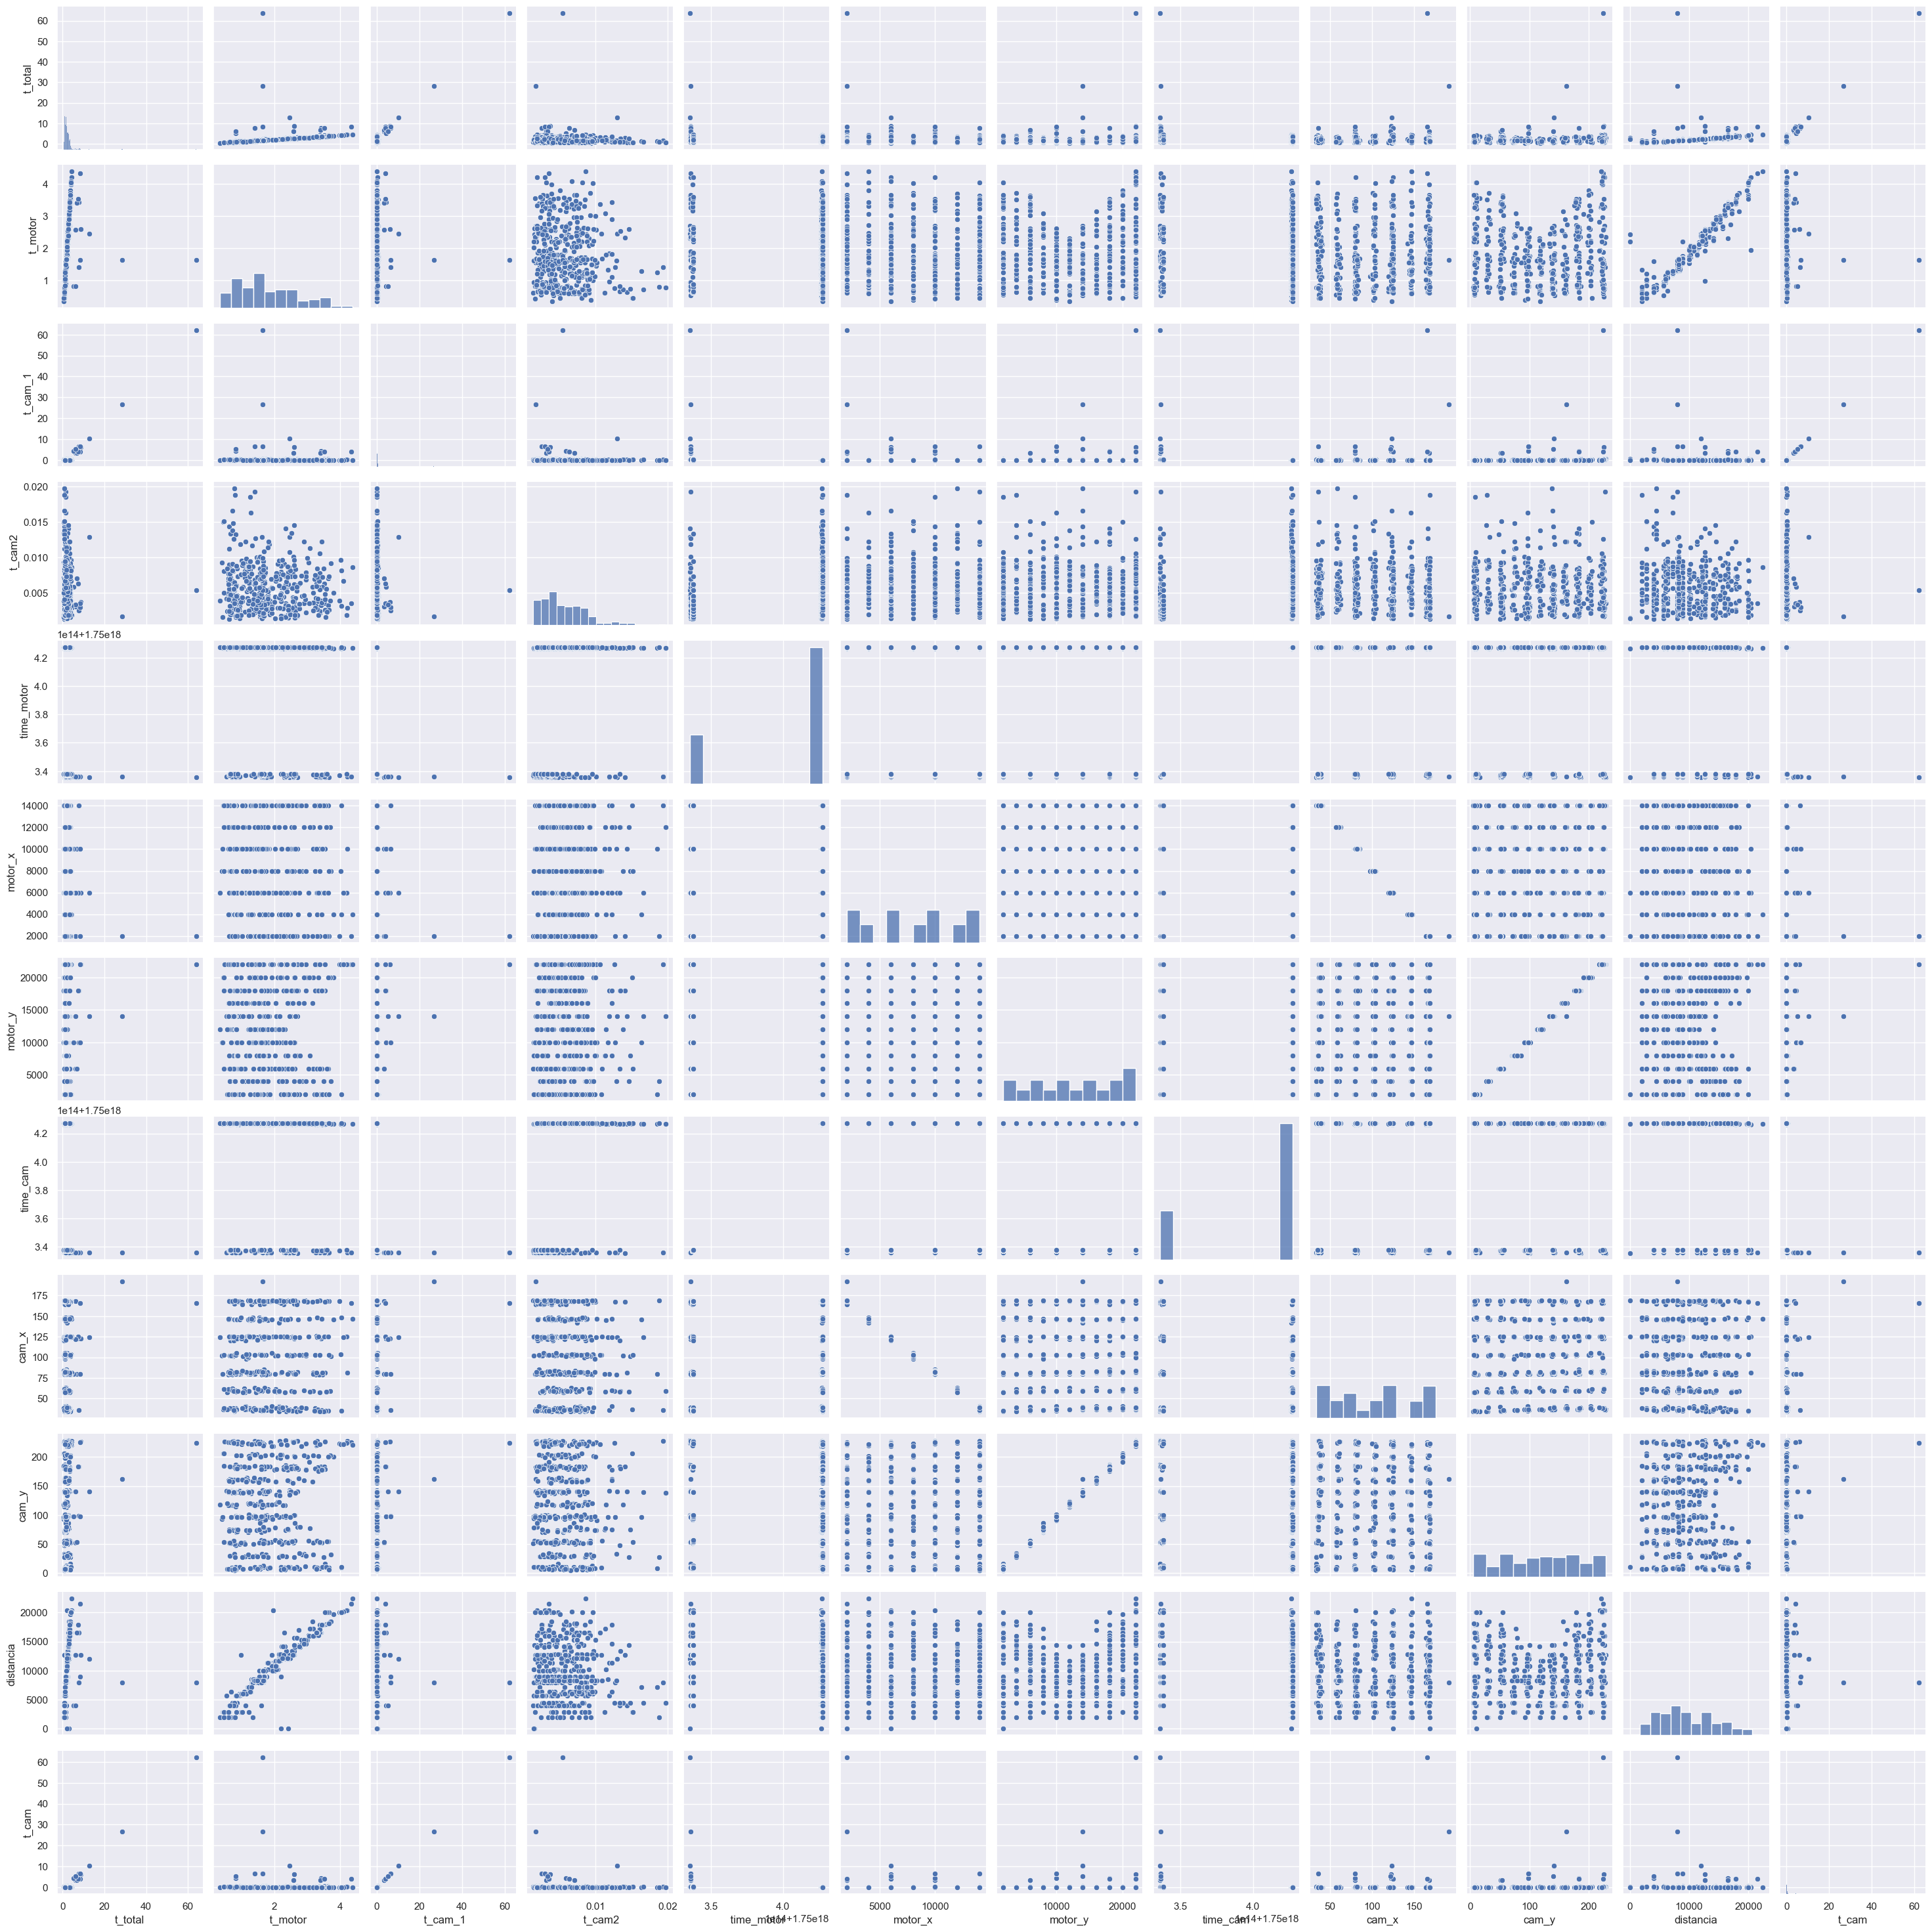

In [76]:
sns.set()
cols = df.columns
sns.pairplot(df[cols], size = 2.5)
plt.show()

c:\ProgramData\anaconda3\envs\DEEPLABCUT\lib\site-packages\seaborn\axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


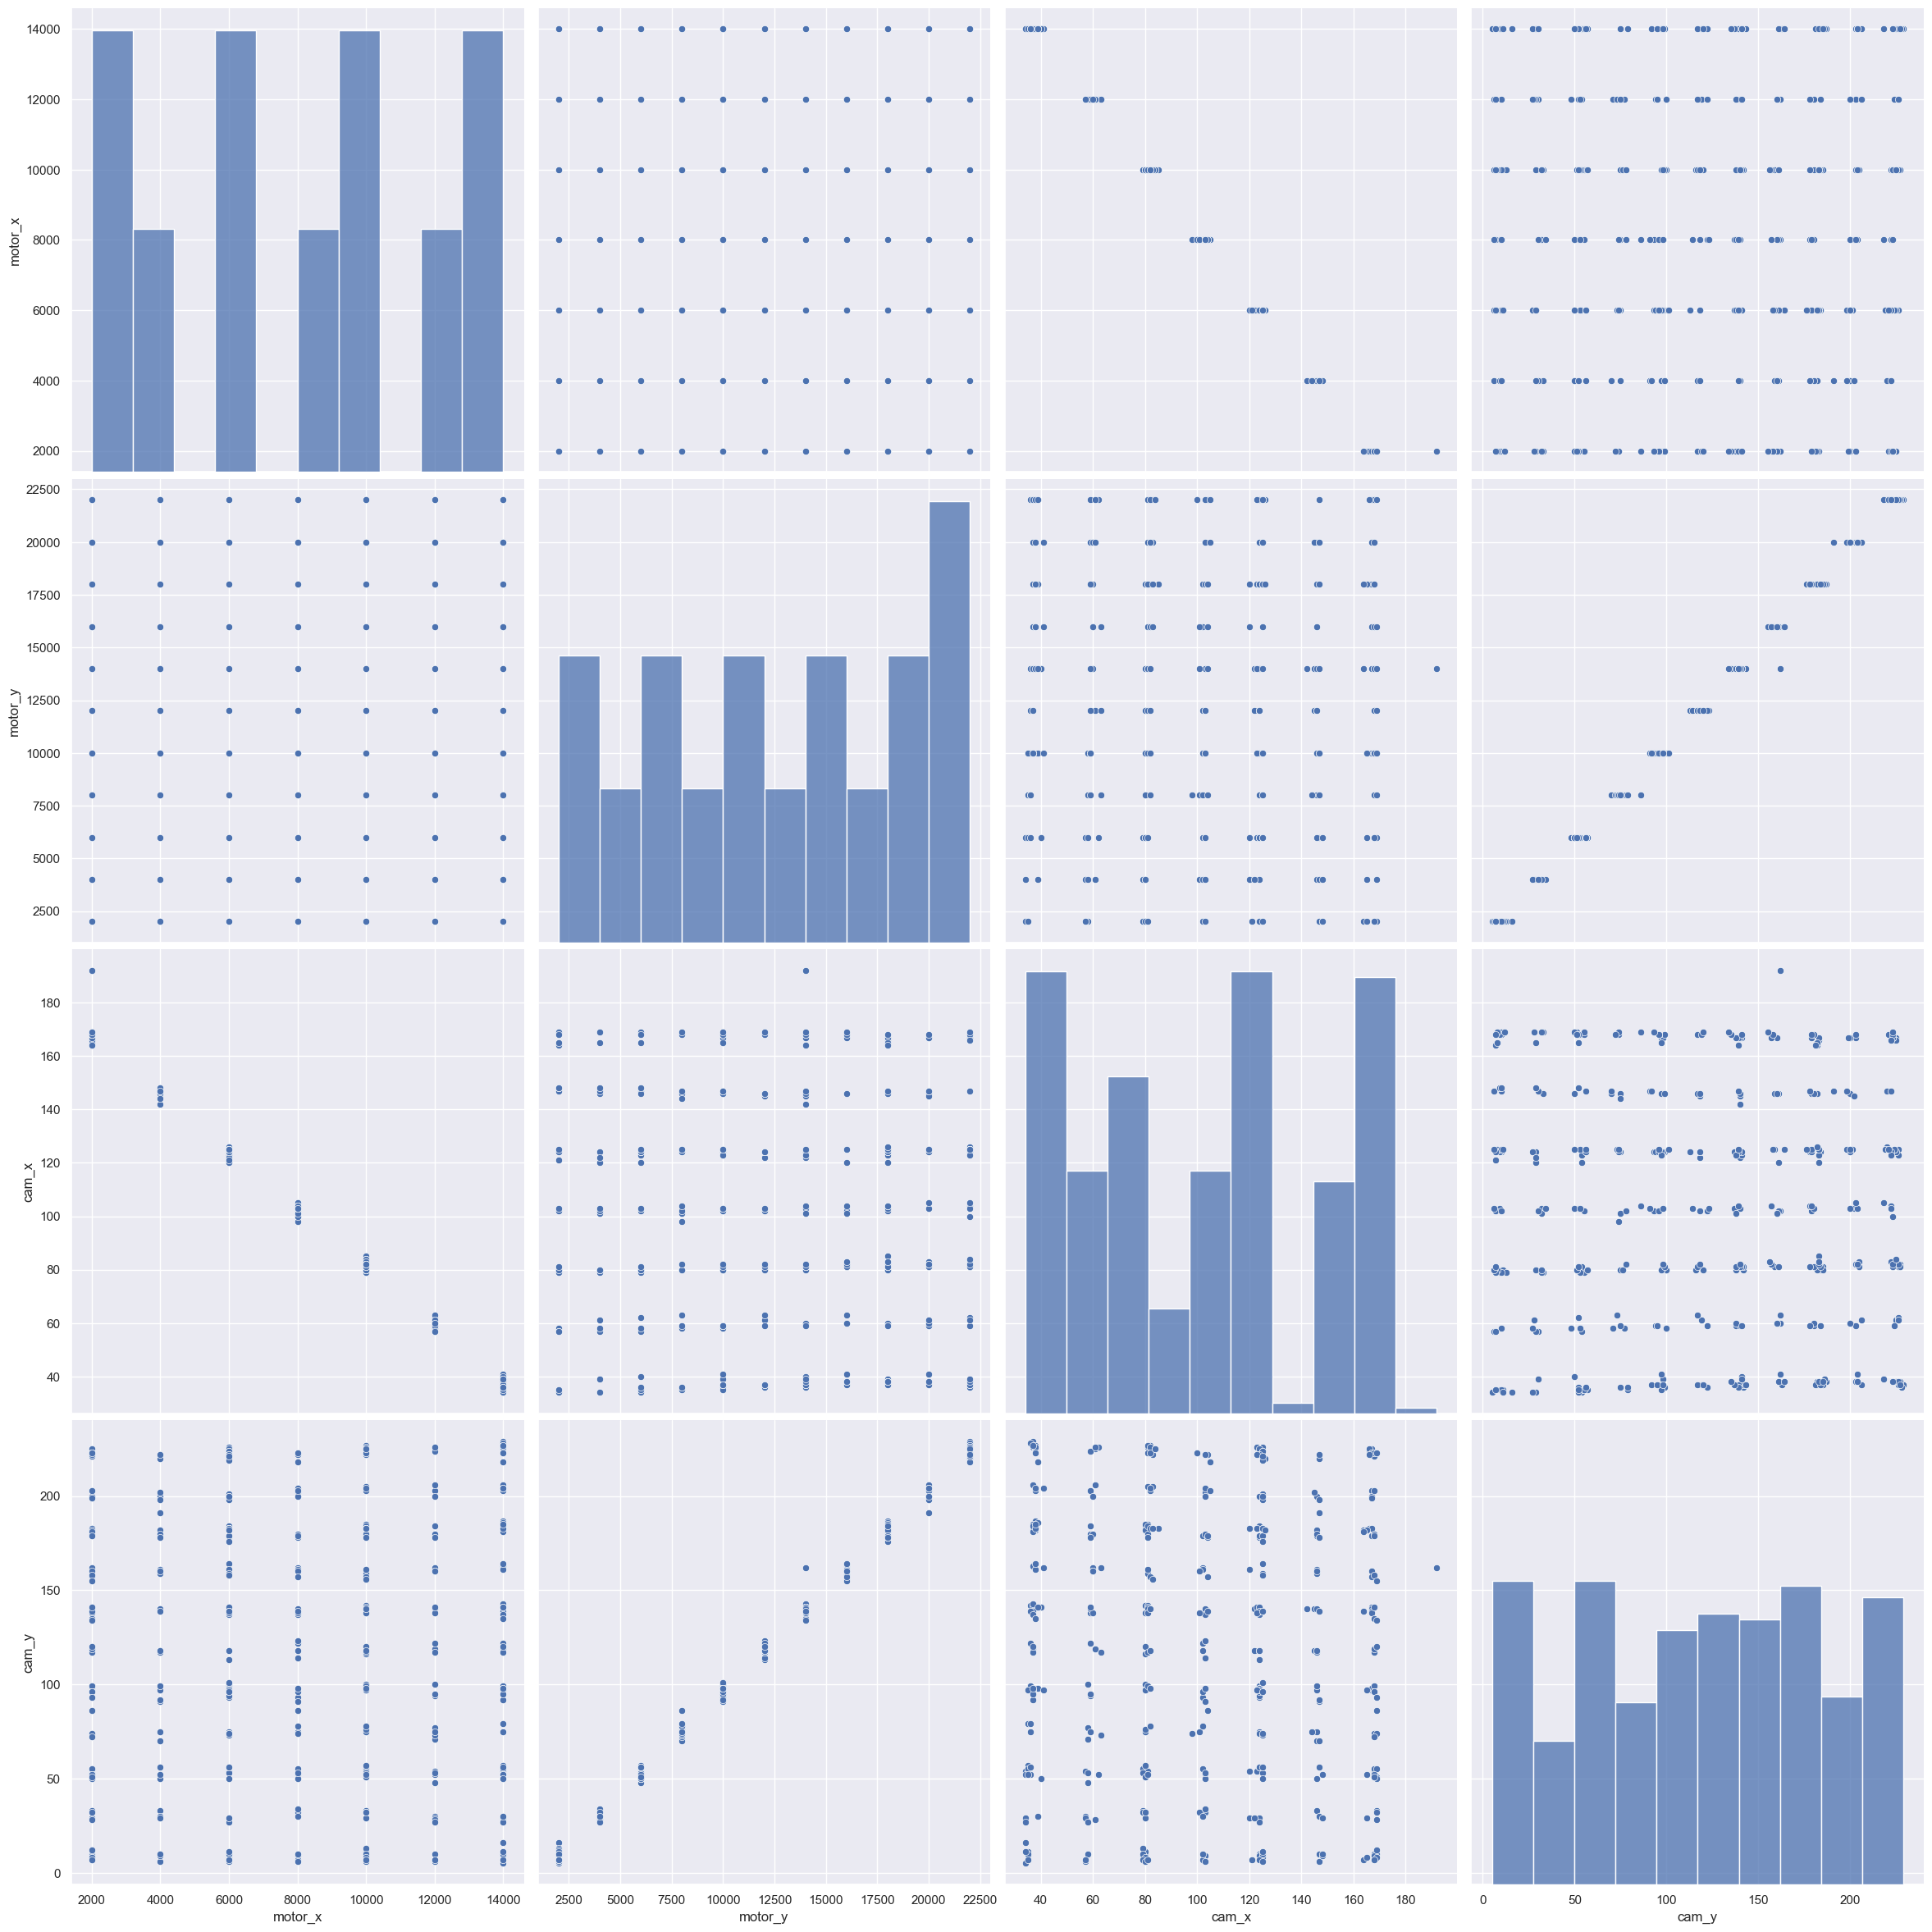

In [77]:
sns.set()
cols = ['motor_x', 'motor_y','cam_x', 'cam_y']
sns.pairplot(df[cols], size = 6)
plt.show()

c:\ProgramData\anaconda3\envs\DEEPLABCUT\lib\site-packages\seaborn\axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


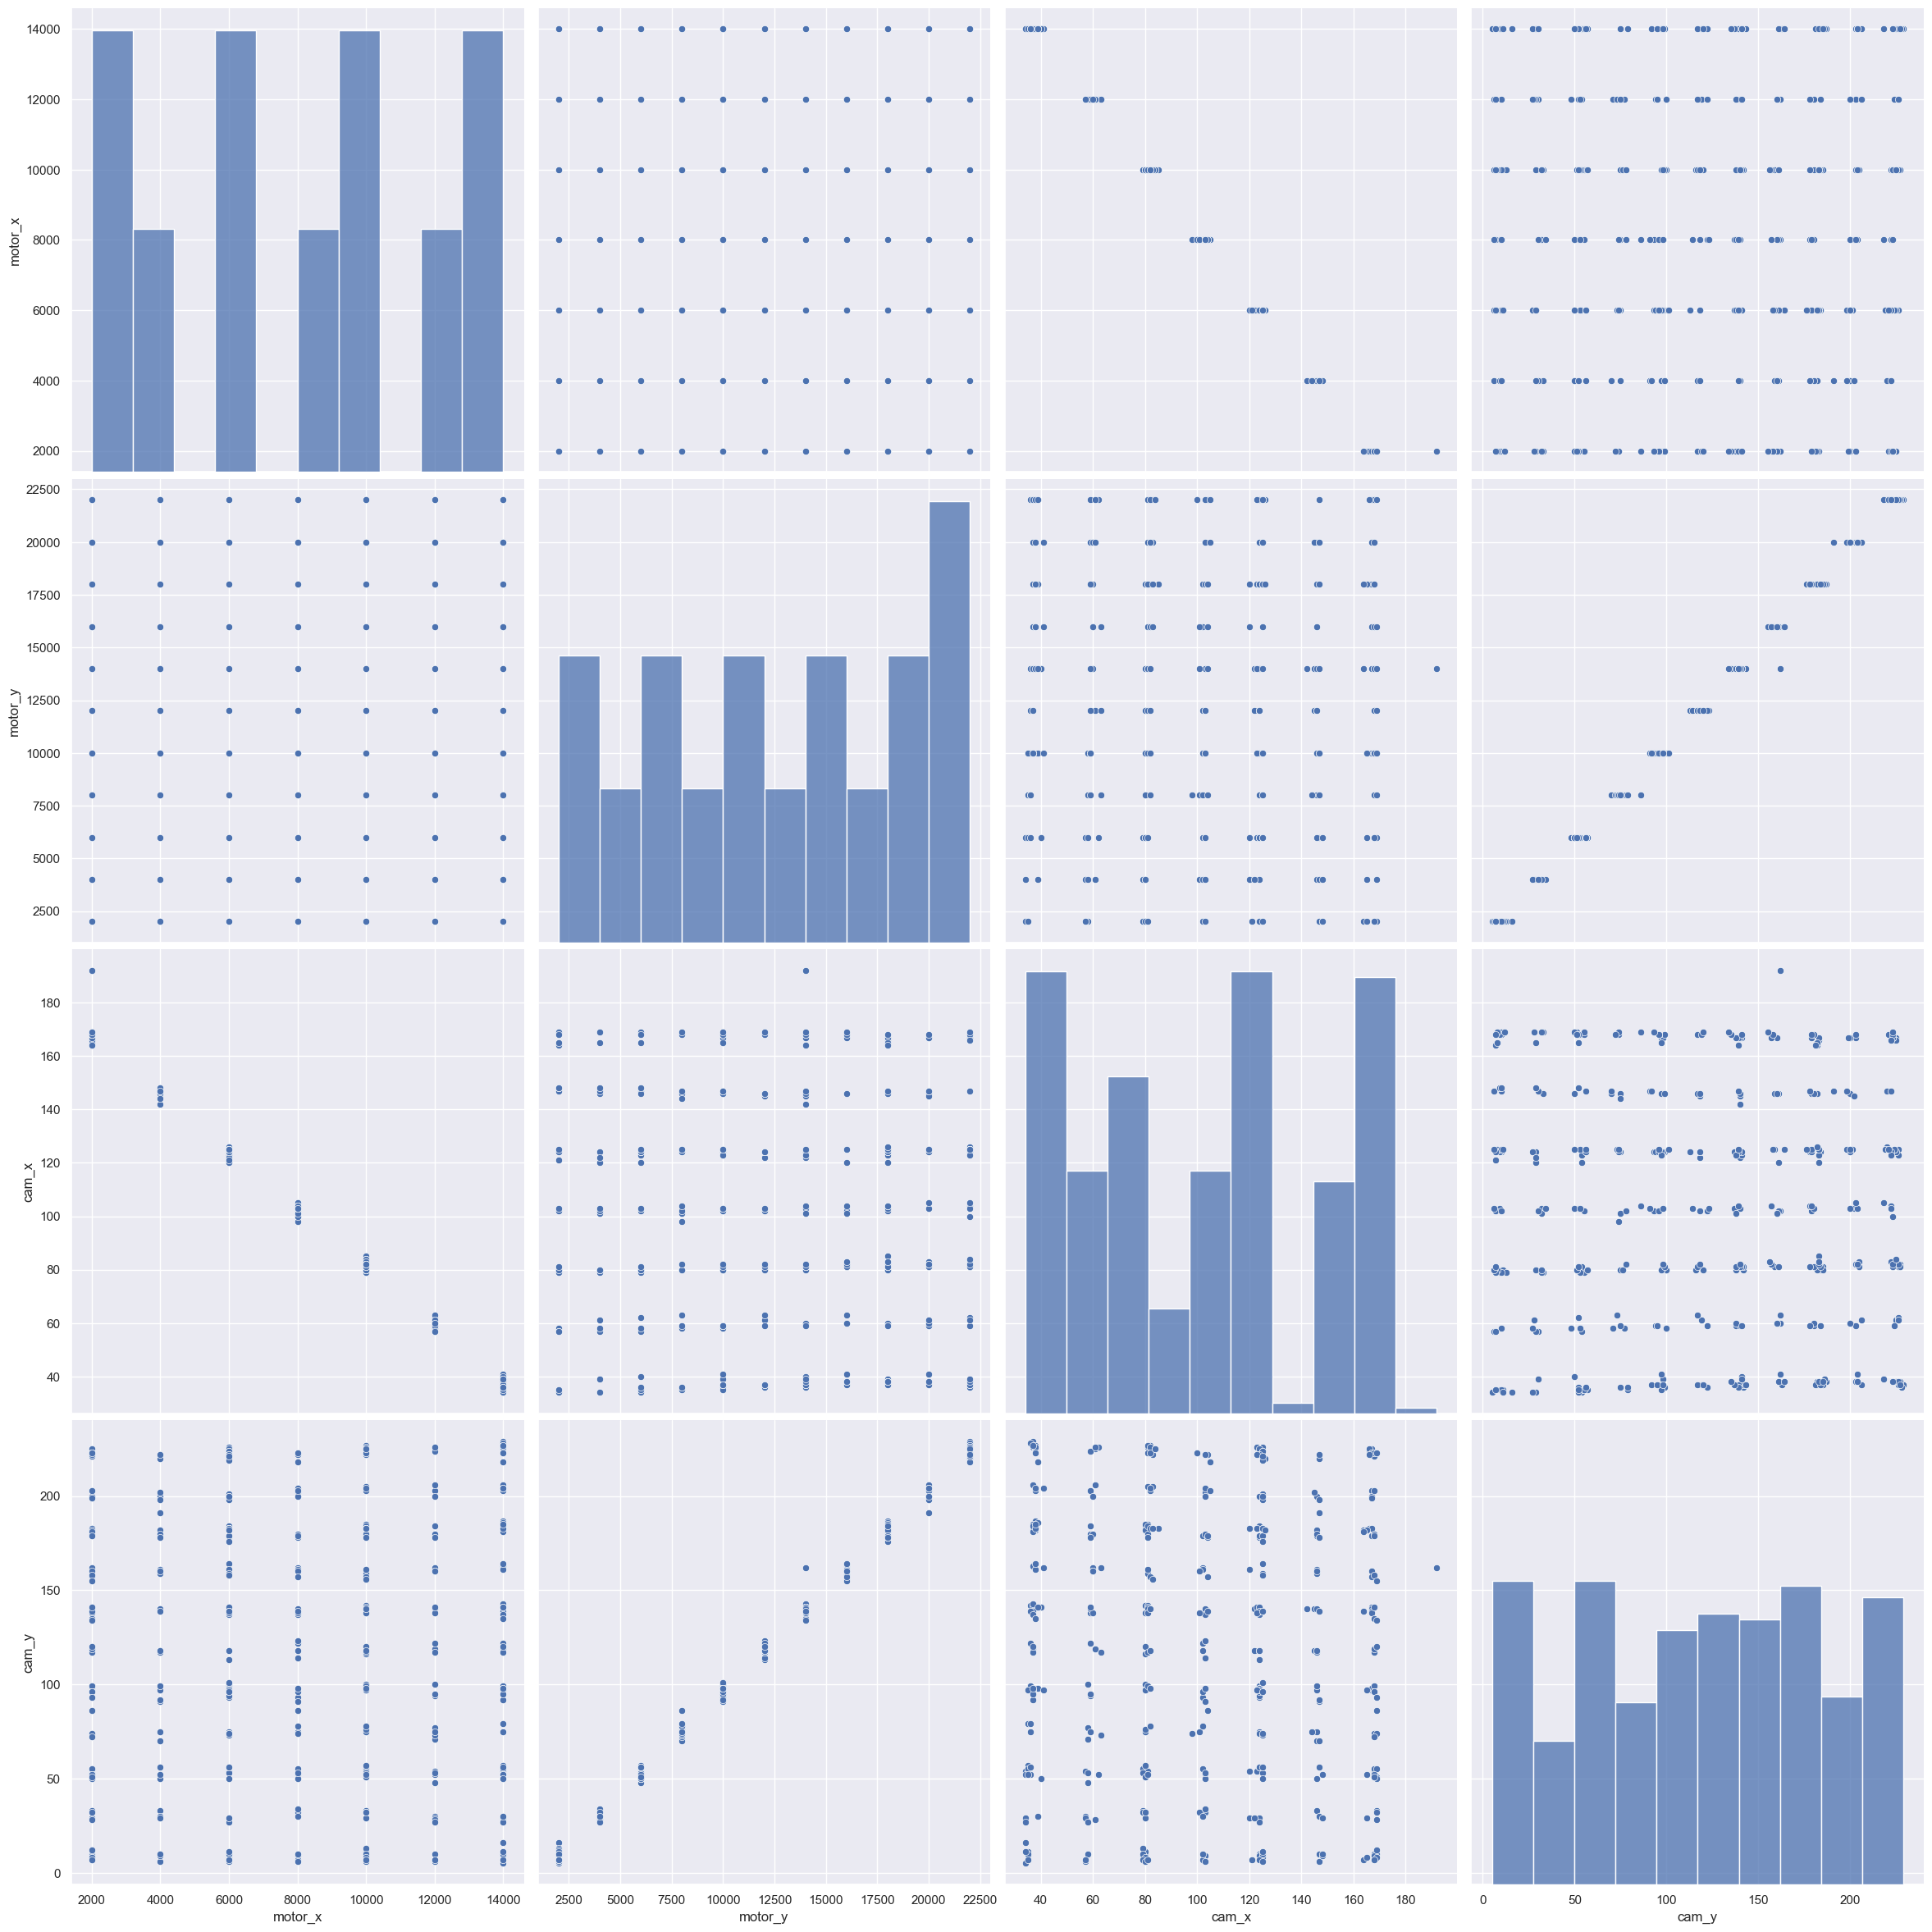

In [78]:
sns.set()
cols = ['motor_x', 'motor_y','cam_x', 'cam_y']
sns.pairplot(df[cols], size = 6)
plt.show()